# Revenue Prediction Analysis: Alberta Fiscal Plan 2026-2029

**Prepared for the Alberta Budget Analysis Project**  
*Analysis of revenue trajectories, composition shifts, and fiscal sustainability risks*

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Set professional style
sns.set_theme(style="whitegrid", context="talk", palette="muted")
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Paths
BASE = Path(r"C:/Users/Casper Ruta/Desktop/Kacper Ruta 2026/Alberta Budget Analysis/Revenue vs Expense Analysis")
DATA = Path(r"C:/Users/Casper Ruta/Desktop/Kacper Ruta 2026/Alberta Budget Analysis/Data")
PLOTS = BASE / "plots"
PLOTS.mkdir(exist_ok=True)

# Color palette - professional blues/teals/warm grays
COLORS = {
    'tax':       '#2B6B8A',   # deep teal
    'resource':  '#D4853B',   # warm amber
    'federal':   '#5B9A6E',   # sage green
    'invest':    '#8B6CAE',   # muted purple
    'other':     '#7A8B8B',   # warm gray
    'revenue':   '#2B6B8A',   # deep teal
    'expense':   '#C05746',   # warm red
    'surplus':   '#5B9A6E',   # sage green
    'deficit':   '#C05746',   # warm red
    'accent':    '#D4853B',   # amber accent
}
CATEGORY_PALETTE = [COLORS['tax'], COLORS['resource'], COLORS['federal'], COLORS['invest'], COLORS['other']]

# Load data
rev_comp = pd.read_csv(BASE / "revenue_comparison.csv")
rev_exp  = pd.read_csv(BASE / "revenue_vs_expense_summary.csv")
rev_detail = pd.read_csv(DATA / "fiscal_plan_2026_revenue.csv")

# Fiscal years for consistent x-axis
FISCAL_YEARS = ['2024-25', '2025-26', '2026-27', '2027-28', '2028-29']

print("Data loaded successfully.")
print(f"  revenue_comparison.csv:       {rev_comp.shape[0]} items")
print(f"  revenue_vs_expense_summary:   {rev_exp.shape[0]} fiscal years")
print(f"  fiscal_plan_2026_revenue:     {rev_detail.shape[0]} rows")

Data loaded successfully.
  revenue_comparison.csv:       16 items
  revenue_vs_expense_summary:   5 fiscal years
  fiscal_plan_2026_revenue:     21 rows


## Revenue Overview

Total revenue trajectory across the five-year fiscal plan, with year-over-year changes and key inflection points.

In [2]:
# Revenue overview table
summary = rev_exp[['Fiscal_Year', 'Total_Revenue', 'Revenue_Change_Pct']].copy()
summary['Revenue_$M'] = summary['Total_Revenue'].apply(lambda x: f"${x:,.0f}M")
summary['YoY_Change'] = summary['Revenue_Change_Pct'].apply(
    lambda x: f"{x:+.1f}%" if pd.notna(x) else "---"
)
# Cumulative change from 2024-25 baseline
baseline = summary.iloc[0]['Total_Revenue']
summary['vs_2024_25'] = ((summary['Total_Revenue'] - baseline) / baseline * 100).apply(
    lambda x: f"{x:+.1f}%" if x != 0 else "Baseline"
)

display_df = summary[['Fiscal_Year', 'Revenue_$M', 'YoY_Change', 'vs_2024_25']].copy()
display_df.columns = ['Fiscal Year', 'Total Revenue', 'Year-over-Year', 'Cumulative vs 2024-25']

print("=" * 72)
print("  ALBERTA REVENUE TRAJECTORY: 2024-25 TO 2028-29")
print("=" * 72)
print(display_df.to_string(index=False))
print("=" * 72)

# Key findings
peak = summary.loc[summary['Total_Revenue'].idxmax()]
trough = summary.loc[summary['Total_Revenue'].idxmin()]
drop_from_peak = (trough['Total_Revenue'] - peak['Total_Revenue']) / peak['Total_Revenue'] * 100

print(f"\n  KEY FINDINGS:")
print(f"  - Peak revenue:   ${peak['Total_Revenue']:,.0f}M in {peak['Fiscal_Year']}")
print(f"  - Trough revenue: ${trough['Total_Revenue']:,.0f}M in {trough['Fiscal_Year']}")
print(f"  - Peak-to-trough decline: {drop_from_peak:.1f}%  (${peak['Total_Revenue'] - trough['Total_Revenue']:,.0f}M)")
print(f"  - Revenue does NOT recover to 2024-25 levels within the forecast window")
print(f"  - By 2028-29, revenue is still ${baseline - summary.iloc[-1]['Total_Revenue']:,.0f}M below the 2024-25 actual")

  ALBERTA REVENUE TRAJECTORY: 2024-25 TO 2028-29
Fiscal Year Total Revenue Year-over-Year Cumulative vs 2024-25
    2024-25      $82,469M            ---              Baseline
    2025-26      $75,292M          -8.7%                 -8.7%
    2026-27      $74,550M          -1.0%                 -9.6%
    2027-28      $78,914M          +5.9%                 -4.3%
    2028-29      $81,518M          +3.3%                 -1.2%

  KEY FINDINGS:
  - Peak revenue:   $82,469M in 2024-25
  - Trough revenue: $74,550M in 2026-27
  - Peak-to-trough decline: -9.6%  ($7,919M)
  - Revenue does NOT recover to 2024-25 levels within the forecast window
  - By 2028-29, revenue is still $951M below the 2024-25 actual


## Revenue Composition Shift

How does Alberta's revenue mix change over the forecast period? Grouping into five major categories reveals the structural shift away from resource revenue.

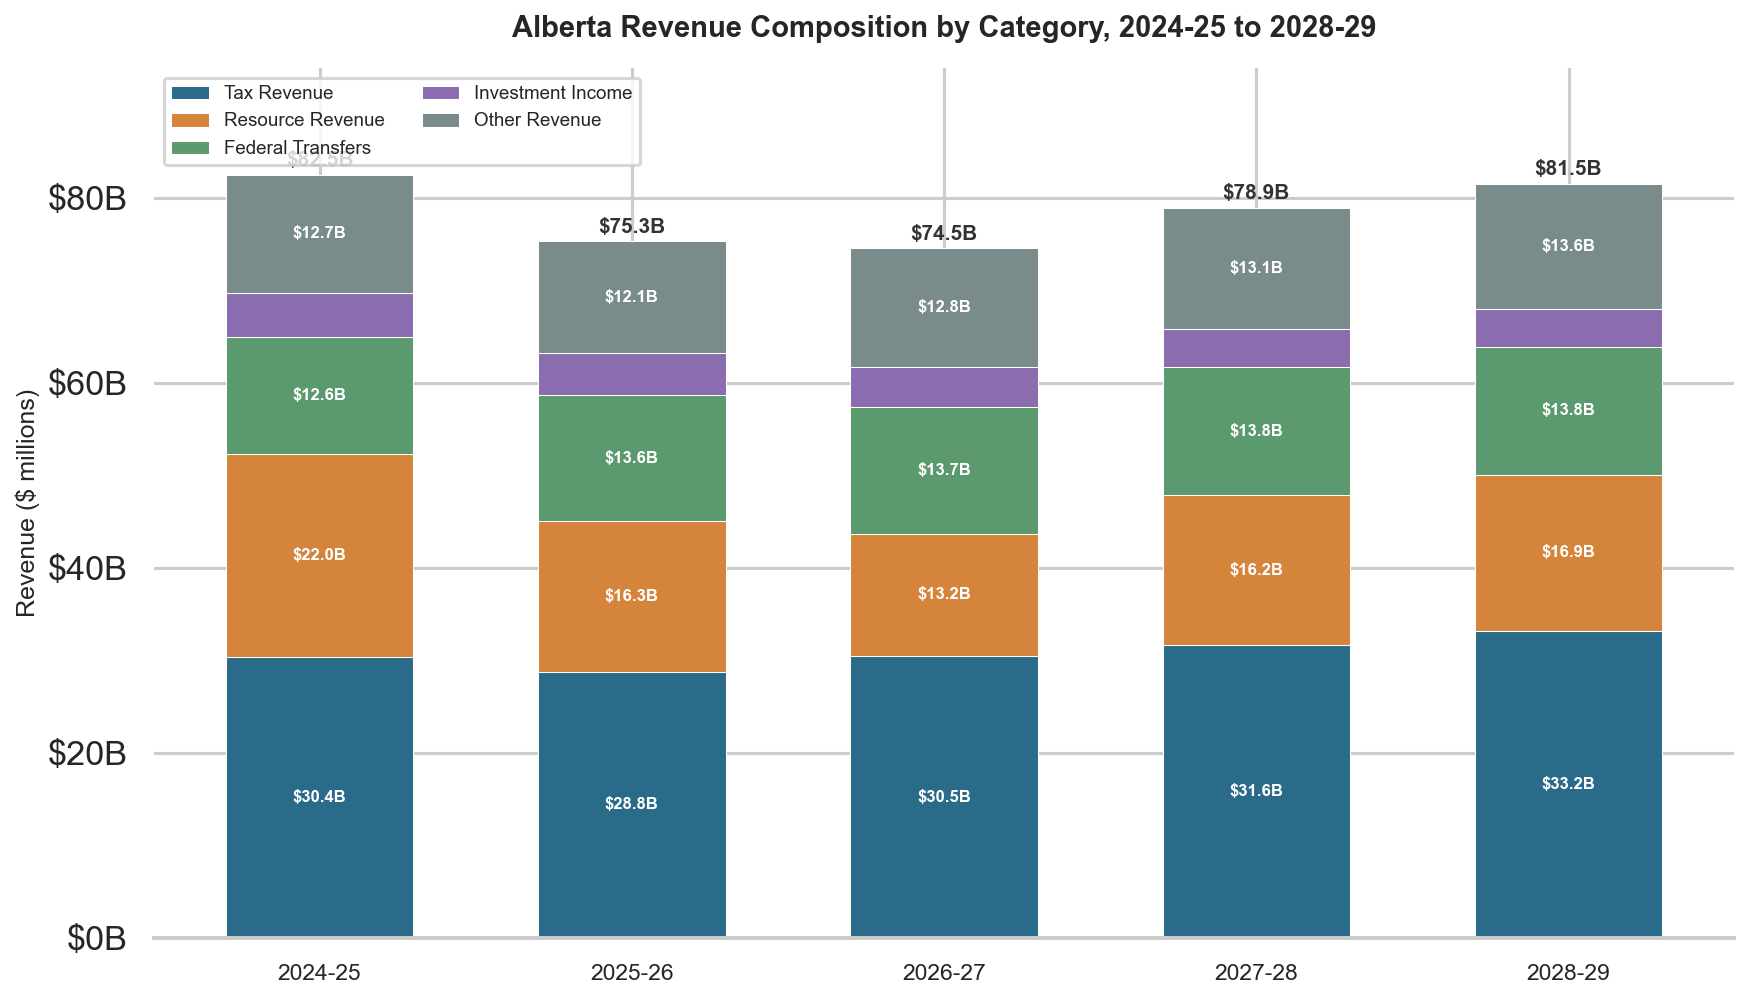


Revenue Share by Category (%):
             Tax Revenue  Resource Revenue  Federal Transfers  Investment Income  Other Revenue
Fiscal Year                                                                                    
2024-25             36.8              26.7               15.3                5.8           15.4
2025-26             38.2              21.6               18.0                6.1           16.0
2026-27             40.9              17.7               18.4                5.8           17.2
2027-28             40.1              20.6               17.5                5.2           16.6
2028-29             40.7              20.7               17.0                5.0           16.6

Resource revenue share drops from 26.7% to 17.7% at the trough.


In [3]:
# Build composition data from the detail CSV (rows with "Total" or "Subtotal" are aggregates)
# Use the category-level totals from rev_detail
year_cols_detail = ['2024-25 Actual', '2025-26 Forecast', '2026-27 Estimate', '2027-28 Target', '2028-29 Target']

# Extract the five category totals
cat_map = {
    'Tax Revenue':       'Total tax revenue',
    'Resource Revenue':  'Total non-renewable resource revenue',
    'Federal Transfers': 'Transfers from Government of Canada',
    'Investment Income': 'Investment income',
}

composition = {}
for label, item_name in cat_map.items():
    row = rev_detail[rev_detail['Item'] == item_name]
    if not row.empty:
        vals = row[year_cols_detail].values.flatten().tolist()
        composition[label] = vals

# "Other Revenue" = Net income from govt business enterprises + Premiums/fees/licences + Other
other_items = [
    'Net income from govt. business enterprises',
    'Premiums, fees and licences',
    'Other',
]
other_sum = np.zeros(5)
for item_name in other_items:
    row = rev_detail[rev_detail['Item'] == item_name]
    if not row.empty:
        other_sum += row[year_cols_detail].values.flatten().astype(float)
composition['Other Revenue'] = other_sum.tolist()

comp_df = pd.DataFrame(composition, index=FISCAL_YEARS)
comp_df.index.name = 'Fiscal Year'

# --- Stacked Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 7))

categories = ['Tax Revenue', 'Resource Revenue', 'Federal Transfers', 'Investment Income', 'Other Revenue']
x = np.arange(len(FISCAL_YEARS))
bar_width = 0.6
bottoms = np.zeros(len(FISCAL_YEARS))

for i, cat in enumerate(categories):
    vals = comp_df[cat].values.astype(float)
    bars = ax.bar(x, vals, bar_width, bottom=bottoms, label=cat,
                  color=CATEGORY_PALETTE[i], edgecolor='white', linewidth=0.5)
    # Annotate each segment with value
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 5000:  # only label segments large enough to read
            ax.text(j, b + v / 2, f'${v/1000:.1f}B', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
    bottoms += vals

# Total label on top
for j, total in enumerate(bottoms):
    ax.text(j, total + 500, f'${total/1000:.1f}B', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(FISCAL_YEARS, fontsize=11)
ax.set_ylabel('Revenue ($ millions)', fontsize=12)
ax.set_title('Alberta Revenue Composition by Category, 2024-25 to 2028-29', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left', frameon=True, fontsize=9, ncol=2)
ax.set_ylim(0, bottoms.max() * 1.14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}B'))
sns.despine(left=True)
plt.tight_layout()
fig.savefig(PLOTS / "revenue_composition.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Print share table
share_df = comp_df.div(comp_df.sum(axis=1), axis=0) * 100
print("\nRevenue Share by Category (%):")
print(share_df.round(1).to_string())
print(f"\nResource revenue share drops from {share_df.loc['2024-25','Resource Revenue']:.1f}% to {share_df.loc['2026-27','Resource Revenue']:.1f}% at the trough.")

## Resource Revenue Risk

Bitumen royalties are the single largest volatile revenue stream. This chart tracks the projected decline and partial recovery of resource revenue.

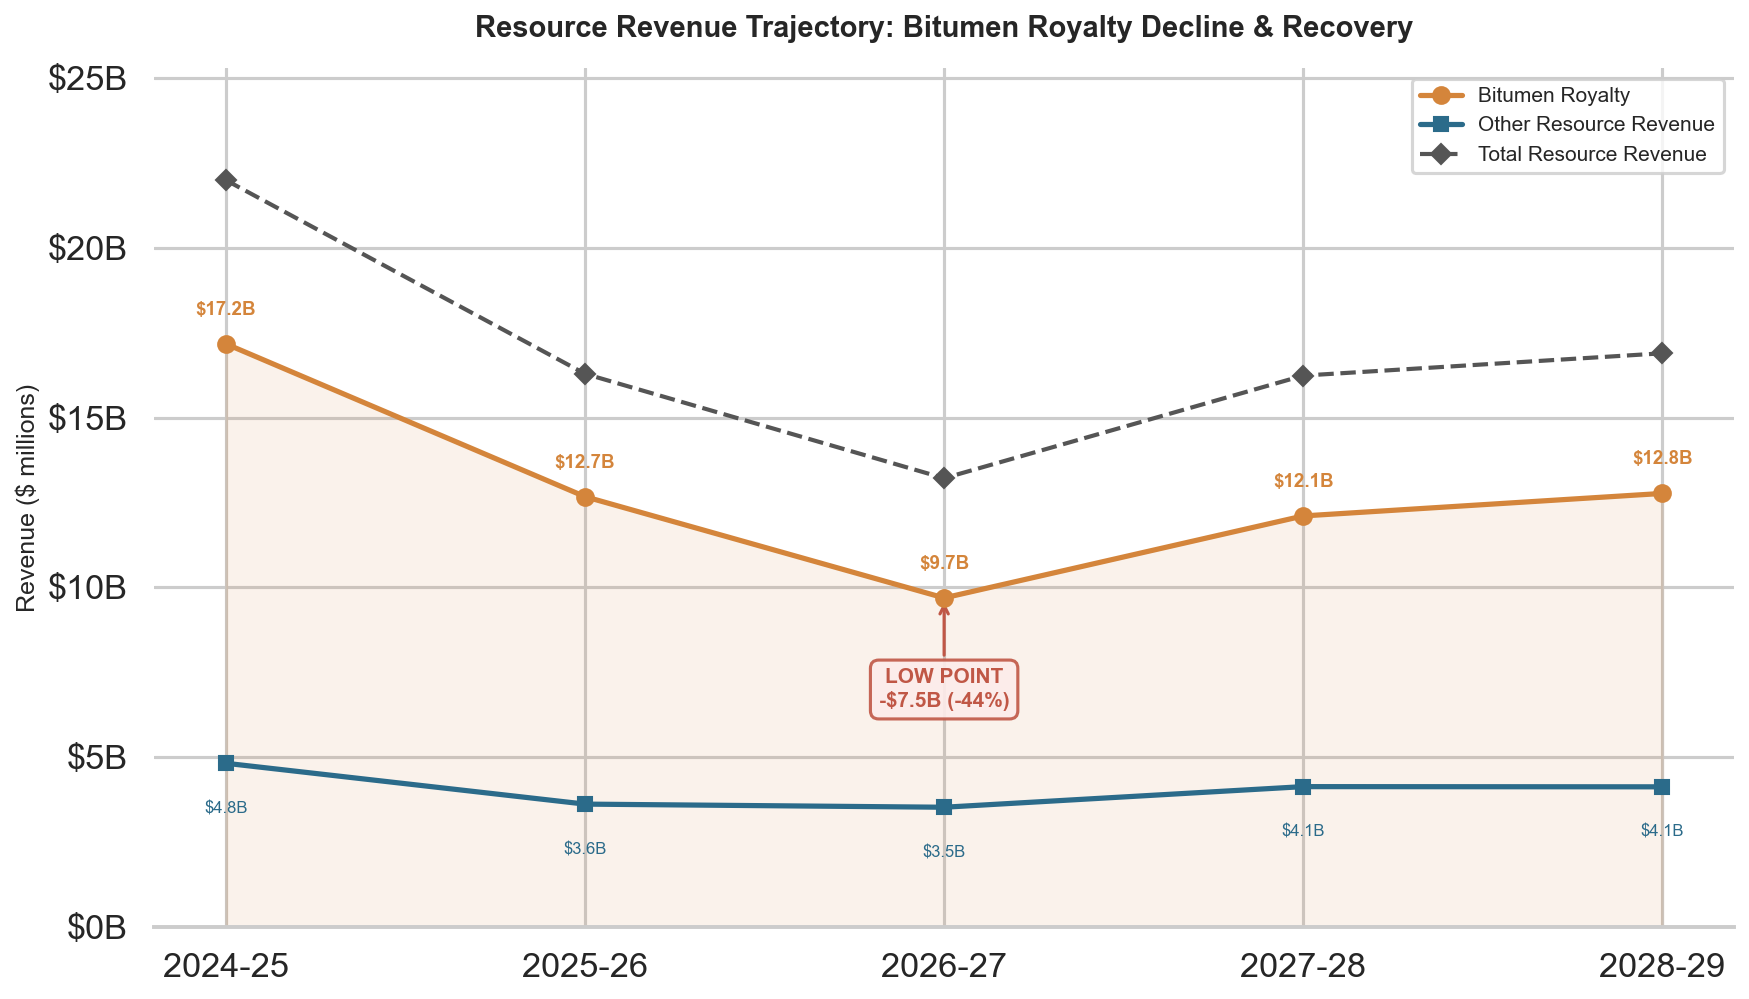

Bitumen royalty falls from $17.2B to $9.7B (-43.6%)
This single item accounts for $7.5B of the total revenue decline.


In [4]:
# Extract bitumen and other resource revenue from rev_comp
year_cols_comp = ['2024-25_Actual', '2025-26_Forecast', '2026-27_Estimate', '2027-28_Target', '2028-29_Target']

bitumen = rev_comp[rev_comp['Item'] == 'Bitumen royalty'][year_cols_comp].values.flatten().astype(float)
other_res = rev_comp[rev_comp['Item'] == 'Other non-renewable resource revenue'][year_cols_comp].values.flatten().astype(float)
total_res = bitumen + other_res

fig, ax = plt.subplots(figsize=(12, 7))

# Lines
ax.plot(FISCAL_YEARS, bitumen, marker='o', markersize=8, linewidth=2.5,
        color=COLORS['resource'], label='Bitumen Royalty', zorder=5)
ax.plot(FISCAL_YEARS, other_res, marker='s', markersize=7, linewidth=2.5,
        color=COLORS['tax'], label='Other Resource Revenue', zorder=5)
ax.plot(FISCAL_YEARS, total_res, marker='D', markersize=7, linewidth=2, linestyle='--',
        color='#555555', label='Total Resource Revenue', zorder=4)

# Fill area under bitumen to emphasize the dip
ax.fill_between(FISCAL_YEARS, bitumen, alpha=0.10, color=COLORS['resource'])

# Annotate data points on bitumen line
for i, (yr, val) in enumerate(zip(FISCAL_YEARS, bitumen)):
    ax.annotate(f'${val/1000:.1f}B', (yr, val),
                textcoords='offset points', xytext=(0, 14),
                ha='center', fontsize=9, fontweight='bold', color=COLORS['resource'])

# Annotate other resource data points
for i, (yr, val) in enumerate(zip(FISCAL_YEARS, other_res)):
    ax.annotate(f'${val/1000:.1f}B', (yr, val),
                textcoords='offset points', xytext=(0, -24),
                ha='center', fontsize=8, color=COLORS['tax'])

# Annotate the low point of bitumen
low_idx = np.argmin(bitumen)
ax.annotate(
    f'LOW POINT\n-${(bitumen[0] - bitumen[low_idx])/1000:.1f}B ({(bitumen[low_idx]/bitumen[0]-1)*100:.0f}%)',
    xy=(FISCAL_YEARS[low_idx], bitumen[low_idx]),
    xytext=(FISCAL_YEARS[low_idx], bitumen[low_idx] - 3200),
    fontsize=10, fontweight='bold', color=COLORS['deficit'],
    ha='center',
    arrowprops=dict(arrowstyle='->', color=COLORS['deficit'], lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FDECEA', edgecolor=COLORS['deficit'], alpha=0.9)
)

ax.set_ylabel('Revenue ($ millions)', fontsize=12)
ax.set_title('Resource Revenue Trajectory: Bitumen Royalty Decline & Recovery',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', frameon=True, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}B'))
ax.set_ylim(0, max(total_res) * 1.15)
sns.despine(left=True)
plt.tight_layout()
fig.savefig(PLOTS / "revenue_resource_risk.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Bitumen royalty falls from ${bitumen[0]/1000:.1f}B to ${bitumen[low_idx]/1000:.1f}B ({(bitumen[low_idx]/bitumen[0]-1)*100:.1f}%)")
print(f"This single item accounts for ${(bitumen[0]-bitumen[low_idx])/1000:.1f}B of the total revenue decline.")

## Revenue vs Expense Gap

The structural deficit emerges as expenses continue to grow while revenue contracts. This chart illustrates the growing fiscal gap.

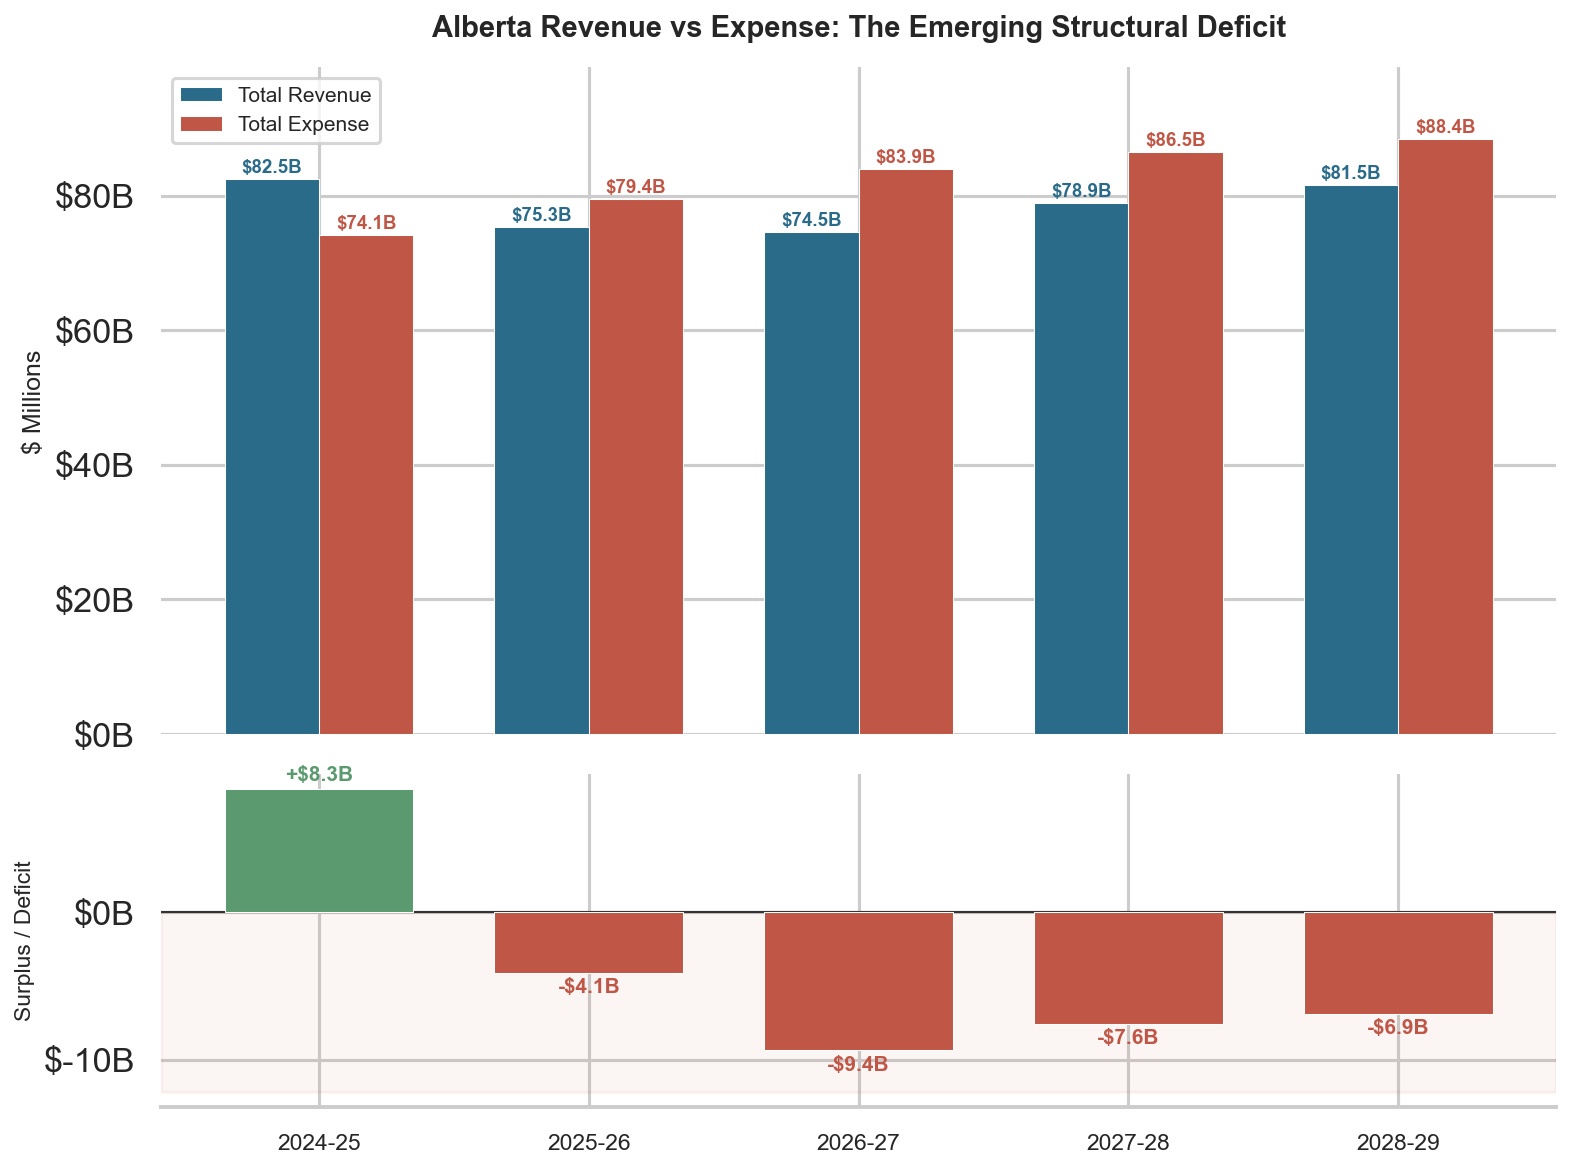

Cumulative projected deficit (2025-26 to 2028-29): $28.0B
Worst year: 2026-27 at -$9.4B


In [5]:
# Revenue vs Expense gap chart
revenue = rev_exp['Total_Revenue'].values.astype(float)
expense = rev_exp['Total_Expense'].values.astype(float)
surplus = rev_exp['Surplus_Deficit'].values.astype(float)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), height_ratios=[3, 1.5],
                                sharex=True, gridspec_kw={'hspace': 0.08})

x = np.arange(len(FISCAL_YEARS))
bar_width = 0.35

# Top panel: Revenue vs Expense bars
bars_rev = ax1.bar(x - bar_width/2, revenue, bar_width, label='Total Revenue',
                   color=COLORS['revenue'], edgecolor='white', linewidth=0.5, zorder=3)
bars_exp = ax1.bar(x + bar_width/2, expense, bar_width, label='Total Expense',
                   color=COLORS['expense'], edgecolor='white', linewidth=0.5, zorder=3)

# Value labels
for i, (r, e) in enumerate(zip(revenue, expense)):
    ax1.text(i - bar_width/2, r + 400, f'${r/1000:.1f}B', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color=COLORS['revenue'])
    ax1.text(i + bar_width/2, e + 400, f'${e/1000:.1f}B', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color=COLORS['expense'])

ax1.set_ylabel('$ Millions', fontsize=12)
ax1.set_title('Alberta Revenue vs Expense: The Emerging Structural Deficit',
              fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='upper left', frameon=True, fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}B'))
ax1.set_ylim(0, max(expense) * 1.12)
sns.despine(ax=ax1, left=True, bottom=True)

# Bottom panel: Surplus/Deficit bars
bar_colors = [COLORS['surplus'] if s >= 0 else COLORS['deficit'] for s in surplus]
bars_sd = ax2.bar(x, surplus, bar_width * 2, color=bar_colors,
                  edgecolor='white', linewidth=0.5, zorder=3)

# Value labels and styling
for i, s in enumerate(surplus):
    offset = 300 if s >= 0 else -300
    va = 'bottom' if s >= 0 else 'top'
    label = f'+${s/1000:.1f}B' if s >= 0 else f'-${abs(s)/1000:.1f}B'
    ax2.text(i, s + offset, label, ha='center', va=va,
             fontsize=10, fontweight='bold',
             color=COLORS['surplus'] if s >= 0 else COLORS['deficit'])

ax2.axhline(y=0, color='#333333', linewidth=1, zorder=2)
ax2.set_ylabel('Surplus / Deficit', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(FISCAL_YEARS, fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}B'))
sns.despine(ax=ax2, left=True)

# Shade deficit region
ax2.axhspan(min(surplus) * 1.3, 0, alpha=0.06, color=COLORS['deficit'], zorder=1)

plt.tight_layout()
fig.savefig(PLOTS / "revenue_vs_expense_gap.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Summary stats
cumulative_deficit = surplus[surplus < 0].sum()
print(f"Cumulative projected deficit (2025-26 to 2028-29): ${abs(cumulative_deficit)/1000:.1f}B")
print(f"Worst year: {FISCAL_YEARS[np.argmin(surplus)]} at -${abs(min(surplus))/1000:.1f}B")

## Key Findings

- **Revenue decline is resource-driven**: Total revenue drops from $82.5B (2024-25) to a trough of $74.6B (2026-27), a $7.9B or 9.6% decline. Bitumen royalty alone accounts for $7.5B of this drop.
- **Structural composition shift**: Resource revenue falls from ~27% of total revenue to ~18% at its lowest point, exposing Alberta's continued vulnerability to commodity price cycles.
- **Tax revenue provides partial offset**: Tax revenue grows modestly from $30.4B to $33.2B (+9.3%) over the period, driven by education property tax and insurance tax increases, but this is insufficient to offset resource losses.
- **Federal transfers are stable**: Transfers from Ottawa grow slowly from $12.6B to $13.8B, providing a steady but limited floor.
- **Cumulative deficit exposure**: The province faces projected deficits totaling ~$28B over four years (2025-26 to 2028-29), with the worst year being 2026-27 at -$9.4B.
- **Asymmetric recovery**: Even by 2028-29, revenue recovers to only $81.5B -- still $1.0B below the 2024-25 actual, while expenses will have grown to $88.4B.
- **Policy implication**: Without new revenue measures or significant expenditure restraint, Alberta faces a persistent structural deficit through the medium term.

In [6]:
# Save key findings for the report writer agent
findings = """REVENUE PREDICTION ANALYSIS: KEY FINDINGS
==========================================
Prepared: 2026-02-26
Source: Alberta Fiscal Plan 2025-2029

1. REVENUE TRAJECTORY
   - Total revenue drops from $82.5B (2024-25 actual) to $74.6B (2026-27 estimate), a 9.6% decline.
   - Partial recovery to $81.5B by 2028-29, but still $1.0B below 2024-25 levels.
   - Year-over-year: -8.7% (2025-26), -1.0% (2026-27), +5.9% (2027-28), +3.3% (2028-29).

2. RESOURCE REVENUE COLLAPSE
   - Bitumen royalty falls from $17.2B to $9.7B (-43.6%), the single largest revenue shock.
   - Other resource revenue declines from $4.8B to $3.5B (-26.9%).
   - Total resource revenue: $22.0B -> $13.2B at trough, recovering to $16.9B by 2028-29.
   - Resource revenue share drops from 26.7% to 17.7% of total revenue.

3. TAX REVENUE (PARTIAL OFFSET)
   - Tax revenue grows from $30.4B to $33.2B (+9.3% over the period).
   - Key growth: education property tax (+28.4%), insurance tax (+16.0%), tourism levy (+58.7%).
   - Key decline: corporate income tax (-10.2%), tobacco/vaping tax (-7.0%).
   - Tax revenue share rises from 36.8% to 40.9%, reflecting a composition shift.

4. FEDERAL TRANSFERS
   - Stable growth from $12.6B to $13.8B (+8.7%).
   - Share rises from 15.3% to 17.0%.

5. FISCAL GAP
   - Alberta moves from $8.3B surplus (2024-25) to deficits of $4.1B to $9.4B.
   - Cumulative deficit 2025-26 to 2028-29: approximately $28.0B.
   - Worst year: 2026-27 at -$9.4B.
   - The gap is driven by revenue declining while expenses grow 7.1%, 5.7%, 3.1%, 2.2% annually.

6. STRUCTURAL RISK
   - The deficit is structural, not cyclical: even with partial resource recovery, expenses 
     outpace revenue through the entire forecast window.
   - Alberta's revenue base remains highly exposed to commodity price volatility.
   - Without policy changes, the province faces persistent deficits.

CHARTS PRODUCED:
   - revenue_composition.png: Stacked bar chart of revenue by category
   - revenue_resource_risk.png: Line chart of bitumen and resource revenue trajectories
   - revenue_vs_expense_gap.png: Dual-panel bar chart showing revenue vs expense and surplus/deficit
"""

findings_path = BASE / "revenue_findings.txt"
with open(findings_path, 'w') as f:
    f.write(findings)

print(f"Findings saved to: {findings_path}")
print("Revenue analysis complete. Three charts saved to plots/ directory.")

Findings saved to: C:\Users\Casper Ruta\Desktop\Kacper Ruta 2026\Alberta Budget Analysis\Revenue vs Expense Analysis\revenue_findings.txt
Revenue analysis complete. Three charts saved to plots/ directory.
